<a href="https://colab.research.google.com/github/YoselineIsa/U1_TorresSilvaYoselineIsabel_A4/blob/main/UNIDAD_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)


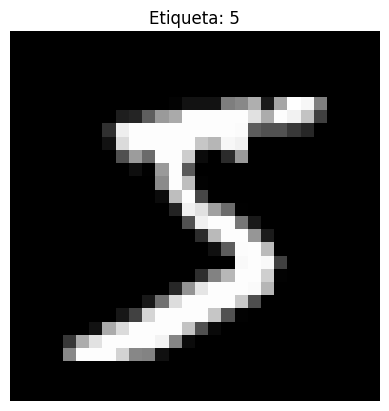

(60000, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8978 - loss: 0.3637 - val_accuracy: 0.9496 - val_loss: 0.1775
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9575 - loss: 0.1464 - val_accuracy: 0.9582 - val_loss: 0.1371
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9699 - loss: 0.1027 - val_accuracy: 0.9661 - val_loss: 0.1113
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9773 - loss: 0.0775 - val_accuracy: 0.9684 - val_loss: 0.1089
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9808 - loss: 0.0633 - val_accuracy: 0.9721 - val_loss: 0.0971
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9857 - loss: 0.0489 - val_accuracy: 0.9741 - val_loss: 0.0891
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9875 - loss: 0.0408 - val_accuracy: 0.9725 - val_loss: 0.0942
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9908 - loss: 0.0305 - val_accuracy: 0.

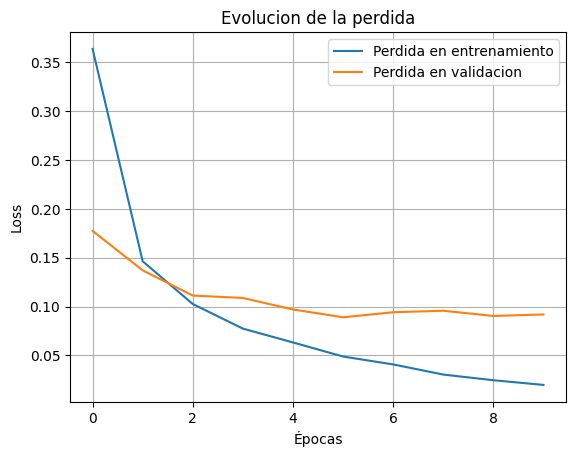

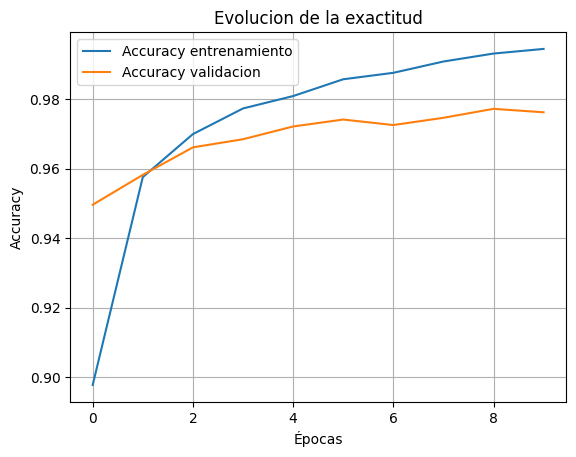

In [ ]:
 #Ejercicio 1

import tensorflow as tf
import matplotlib.pyplot as plt


#Cargar MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape)
print("Test:", x_test.shape)

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0


x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
 ])

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

#PARTE 7 EVALUACION DEL MODELO

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("precisiòn en test:", test_accuracy)

#PARTE 8 PREDICCION Y ANALISIS

import numpy as np

pred = model.predict(x_test)
predicted_label = np.argmax(pred[0])

print("Prediccion: ", predicted_label)
print("Etiqueta real: ", y_test[0])

#PARTE 9 GUARDADO DEL MODELO (DESPLIEGUE BASICO)

model.save("mlp_mnist.keras")

#PARTE 10  GRAFICA DE PERDIDA

import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['loss'], label='Perdida en entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida en validacion')
plt.title('Evolucion de la perdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#Grafica de exactitud

plt.figure()
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validacion')
plt.title('Evolucion de la exactitud')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Parte 2 - Carga de datos
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Train:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28)


In [ ]:
#Prepocesamiento
  #normalizacion
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
#Dimensiones
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


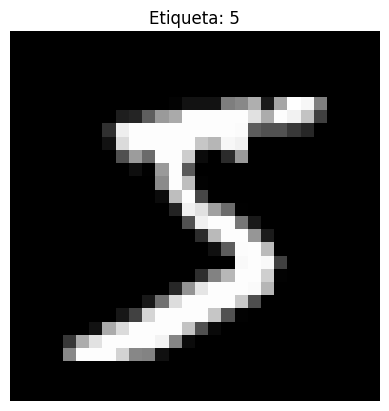

In [ ]:
#Parte 3 - Visualizacion de la imagen
import matplotlib.pyplot as plt
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

In [ ]:
#Parte 4 - Creacion de la arquitectura

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Parte 5 - Compilacion del modelo

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
#Parte 6 - Entrenamiento
History = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.9195 - loss: 0.2626 - val_accuracy: 0.9810 - val_loss: 0.0645
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9707 - loss: 0.0958 - val_accuracy: 0.9846 - val_loss: 0.0531
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9793 - loss: 0.0706 - val_accuracy: 0.9866 - val_loss: 0.0458
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.9819 - loss: 0.0589 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9853 - loss: 0.0493 - val_accuracy: 0.9897 - val_loss: 0.0339
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9870 - loss: 0.0408 - val_accuracy: 0.9896 - val_loss: 0.0370
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.9868 - val_loss: 0.0471
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9897 - loss: 0.0326 - 

In [ ]:
# Parte 7 - Evaluacion.

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy en test:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9929 - loss: 0.0234
Accuracy en test: 0.992900013923645


In [ ]:
#Parte 8 - Prediccion y analisis

import numpy as np

pred = model.predict(x_test)
print("Prediccion: ", np.argmax(pred[0]))
print("Etiqueta real: ", y_test[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediccion:  7
Etiqueta real:  7


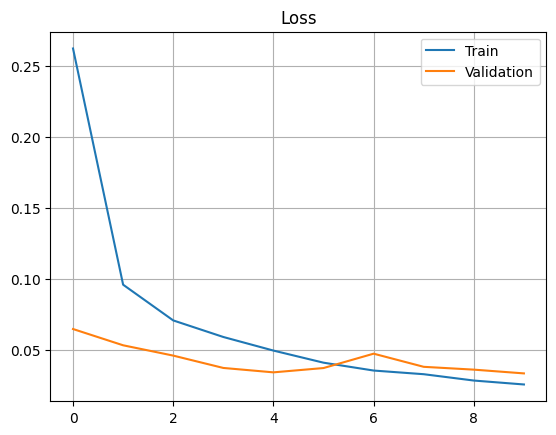

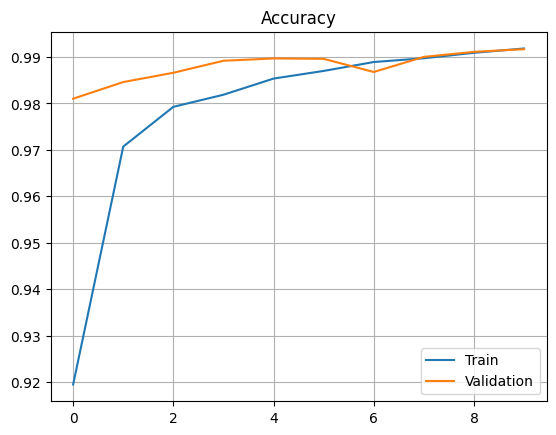

In [ ]:
import matplotlib.pyplot as plt

#loss
plt.figure()
plt.plot(History.history['loss'], label='Train')
plt.plot(History.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.grid()
plt.show()

#accuracy
plt.figure()
plt.plot(History.history['accuracy'], label='Train')
plt.plot(History.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Parte 10 - Guardado del modelo
model.save("cnn_mnist.keras")

In [ ]:
#Ejemplo en Keras (Feature Extraction)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Cargar el modelo pre-entrenado VGG16
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224,3))
base_model.trainable = False

# Crear un nuevo modelo
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Ejercicio 1 - Inspeccion de filtros aprendidos
Entrena para este ejercicio se construyo una Red Neuronal Convolucional para ser entrenada con el dataset MNIST y extraeremos los pesos de la primera capa.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9269 - loss: 0.2654
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9736 - loss: 0.0912
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9807 - loss: 0.0671
Forma de los filtros: (3, 3, 1, 32)


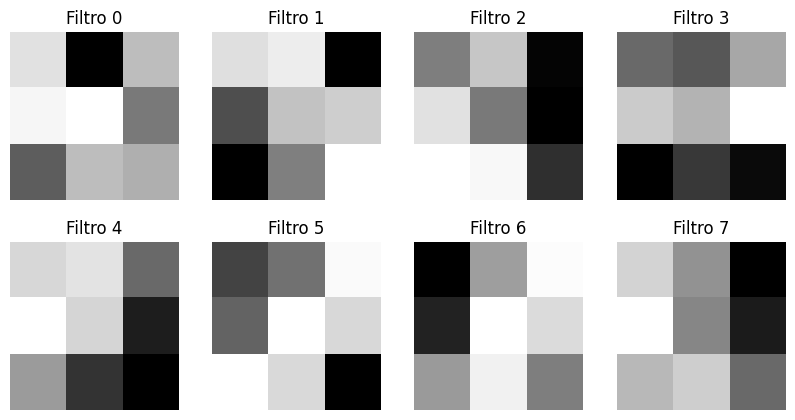

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar y normalizar MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Redimensionar para la CNN (28x28x1)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# 2. Definir una CNN sencilla
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Entrenar el modelo
model.fit(x_train, y_train, epochs=3, batch_size=64)

# 4. Inspeccionar filtros de la primera capa
filters, biases = model.layers[0].get_weights()
print(f"Forma de los filtros: {filters.shape}") # (3, 3, 1, 32)

# Visualizar los primeros 8 filtros
plt.figure(figsize=(10, 5))
for i in range(8):
    f = filters[:, :, 0, i]
    plt.subplot(2, 4, i+1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
    plt.title(f'Filtro {i}')
plt.show()

Para comparar la salida (mapas de características) antes y después del entrenamiento


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


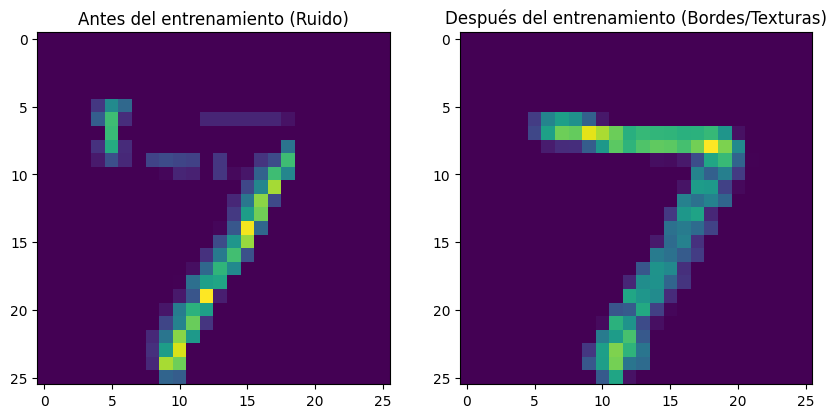

In [5]:
# Crear un modelo idéntico pero con pesos aleatorios (sin entrenar)
model_random = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
])

# Elegir una imagen de prueba
img = x_test[0:1]

# Ensure model_random is built by calling it with input
_ = model_random(img) # Call with dummy input, ignore output

# Create an explicit Input tensor that matches the original model's input shape
input_for_extractor = tf.keras.Input(shape=(28, 28, 1))

# Get the first Conv2D layer from the trained model
first_conv_layer = model.layers[0]

# Pass the explicit input tensor through the first convolutional layer
output_of_first_layer = first_conv_layer(input_for_extractor)

# Create the activation model using the explicit input and the output of the first layer
activation_model = models.Model(inputs=input_for_extractor, outputs=output_of_first_layer)

# Obtener activaciones
act_random = model_random.predict(img)
act_trained = activation_model.predict(img)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(act_random[0, :, :, 0], cmap='viridis')
axes[0].set_title("Antes del entrenamiento (Ruido)")
axes[1].imshow(act_trained[0, :, :, 0], cmap='viridis')
axes[1].set_title("Después del entrenamiento (Bordes/Texturas)")
plt.show()

¿Por qué los primeros filtros parecen bordes?
para que la red pueda identificar un "3" o un "8", primero debe "dibujar" el contorno del número, por lo que la optimización guía a los filtros iniciales a especializarse en líneas verticales, horizontales y diagonales.

¿Qué tipo de patrones aprenderán capas profundas?
Capas intermedias: Aprenden formas geométricas, curvas, círculos o esquinas.

Capas finales: Aprenden estructuras completas u objetos. En el caso de MNIST, aprenderían representaciones abstractas de los dígitos completos (la estructura de un "4" vs un "9").

**EJERCICIO 2 - Experimento comparativo**

In [ ]:
Entrena dos CNN: MaxPooling2D y AveragePooling2D

Entrenando modelo con MaxPooling...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con AveragePooling...


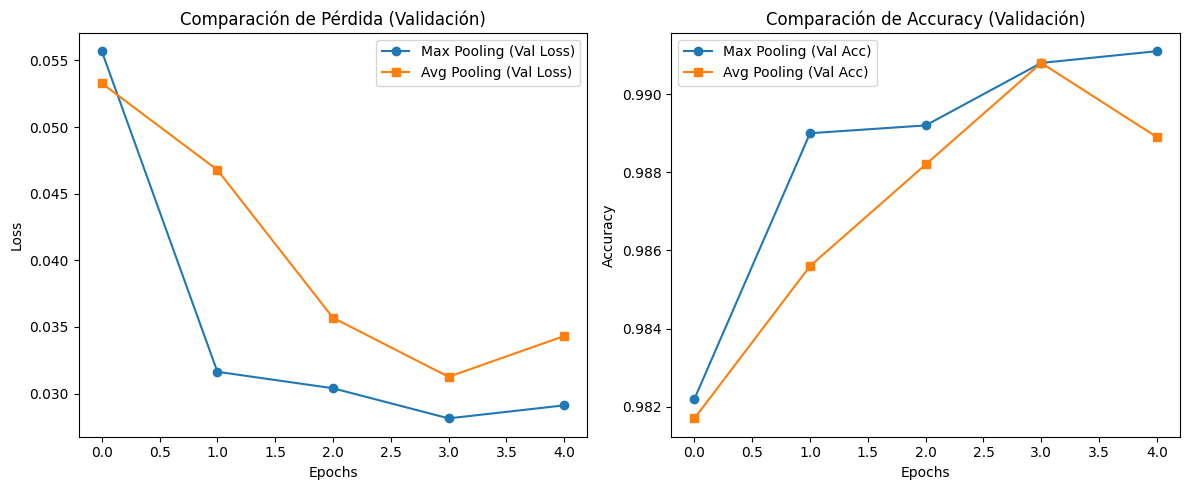


Accuracy Final Max Pooling: 0.9911
Accuracy Final Average Pooling: 0.9889


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Preparación de datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# 2. Función para crear modelos (cambiando solo la capa de pooling)
def build_model(pooling_type):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)) if pooling_type == 'max' else layers.AveragePooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)) if pooling_type == 'max' else layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. Entrenar ambas redes
epochs = 5
print("Entrenando modelo con MaxPooling...")
model_max = build_model('max')
history_max = model_max.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=0)

print("Entrenando modelo con AveragePooling...")
model_avg = build_model('avg')
history_avg = model_avg.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=0)

# 4. Comparación de Resultados
# --- Gráfica de Pérdida (Loss) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_max.history['val_loss'], label='Max Pooling (Val Loss)', marker='o')
plt.plot(history_avg.history['val_loss'], label='Avg Pooling (Val Loss)', marker='s')
plt.title('Comparación de Pérdida (Validación)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Gráfica de Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history_max.history['val_accuracy'], label='Max Pooling (Val Acc)', marker='o')
plt.plot(history_avg.history['val_accuracy'], label='Avg Pooling (Val Acc)', marker='s')
plt.title('Comparación de Accuracy (Validación)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Resumen final en consola
print(f"\nAccuracy Final Max Pooling: {history_max.history['val_accuracy'][-1]:.4f}")
print(f"Accuracy Final Average Pooling: {history_avg.history['val_accuracy'][-1]:.4f}")

Curvas de Pérdida (Loss): la curva de MaxPooling desciende de forma más agresiva en las primeras épocas. Esto se debe a que las señales de los bordes (fundamentales en MNIST) se transmiten con mayor claridad hacia las capas densas.

Accuracy: En MNIST, ambos modelos tendrán un desempeño muy alto (arriba del 97%), pero el de Max Pooling suele mantener una ligera ventaja o alcanzar la convergencia en menos pasos.

**Ejercicio 3 - Eliminacion Pooling**

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Modelo con Pooling (Referencia)
model_pooling = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Reducción aquí
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

# 2. Modelo sin Pooling (usando strides=2)
model_strides = models.Sequential([
    # Al usar strides=(2,2), la salida se reduce a la mitad sin necesidad de pooling
    layers.Conv2D(32, (3, 3), strides=(2, 2), activation='relu', input_shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model_pooling.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_strides.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Análisis de impacto en parámetros
model_pooling.summary()
model_strides.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

¿Por qué pooling afecta la retropropagación?
el Max Pooling introduce una operación no lineal que actúa como un "interruptor". Durante el backpropagation, el gradiente solo fluye a través del elemento que fue el máximo en el paso hacia adelante forward pass. Los demás elementos de la ventana reciben un gradiente de cero. Esto significa que el pooling selecciona qué rutas de información se actualizan, lo que ayuda a la invariancia espacial pero descarta mucha información del gradiente para las neuronas "no ganadoras".

¿Qué ocurre si se elimina completamente?
Si eliminas el pooling y no usas strides > 1:

Explosión de parámetros

*   Explosion de parametros
*   Perdida de Invariancia





**Ejercicio 1: CNN Simple vs. VGG16**

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import numpy as np

# ==========================================
# 1. CARGA Y PREPROCESAMIENTO SEGURO
# ==========================================
# Usamos MNIST (como en las diapositivas anteriores)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

def preprocess_for_vgg(images):
    # 1. Normalizar a [0, 1]
    images = images.astype('float32') / 255.0
    # 2. VGG16 requiere 3 canales (RGB). Repetimos el canal de gris.
    images = np.stack((images,) * 3, axis=-1)
    # 3. VGG16 requiere mínimo 32x32 píxeles. Redimensionamos de 28x28 a 32x32.
    images = tf.image.resize(images, [32, 32]).numpy()
    return images

print("Adaptando imágenes para VGG16 (esto puede tardar un poco)...")
x_train_vgg = preprocess_for_vgg(x_train[:10000]) # Usamos 10k para no agotar la RAM
y_train_vgg = y_train[:10000]
x_test_vgg = preprocess_for_vgg(x_test[:2000])
y_test_vgg = y_test[:2000]

# ==========================================
# 2. MODELO VGG16 CORREGIDO
# ==========================================
# include_top=False elimina la capa final de 1000 clases de ImageNet
base_model = applications.VGG16(weights='imagenet',
                                include_top=False,
                                input_shape=(32, 32, 3))

# Congelamos los pesos para que sea Transfer Learning real
base_model.trainable = False

model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Añadimos Dropout para evitar el sobreajuste (Reflexión Ej. 3)
    layers.Dense(10, activation='softmax')
])

model_vgg.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# ==========================================
# 3. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento del modelo corregido...")
model_vgg.fit(x_train_vgg, y_train_vgg,
              epochs=3,
              batch_size=32,
              validation_data=(x_test_vgg, y_test_vgg))

model_vgg.summary()

Adaptando imágenes para VGG16 (esto puede tardar un poco)...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Iniciando entrenamiento del modelo corregido...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 525ms/step - accuracy: 0.7200 - loss: 0.8867 - val_accuracy: 0.8605 - val_loss: 0.4713
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 185s 468ms/step - accuracy: 0.8802 - loss: 0.4109 - val_accuracy: 0.8970 - val_loss: 0.3320
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 163s 522ms/step - accuracy: 0.9022 - loss: 0.3169 - val_accuracy: 0.9230 - val_loss: 0.2610


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)

Parámetros vs. Accuracy
Modelo Simple: Tendrá pocos parámetros (puedes verlos en summary()). Su precisión suele estancarse rápido porque "no sabe nada" al empezar.
VGG16: Aunque tiene millones de parámetros, solo entrenamos una pequeña parte. El accuracy en validación suele subir mucho más rápido porque el modelo ya reconoce bordes, texturas y formas complejas.

¿Más profunda es mejor?
Una red demasiado profunda para un problema sencillo puede causar:

Desvanecimiento del gradiente: La señal de error se pierde antes de llegar a las primeras capas.

Overfitting: El modelo se "aprende de memoria" las fotos de entrenamiento pero falla con fotos nuevas.

Inestabilidad: Requiere más datos y hardware potente para converger correctamente.

**Ejercicio 5: Comparativa con y sin Dropout**






Entrenando modelo SIN Dropout...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo CON Dropout (0.5)...


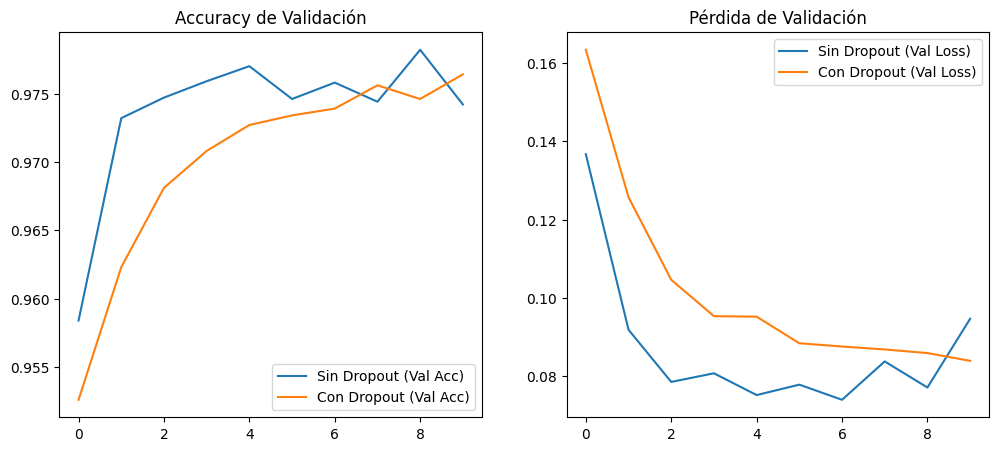

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Preparar datos
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Función para crear modelos
def crear_modelo(con_dropout=False):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))
    model.add(layers.Dense(128, activation='relu'))
    if con_dropout:
        model.add(layers.Dropout(0.5)) # Ejercicio 1: Dropout = 0.5
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Entrenar ambos
print("Entrenando modelo SIN Dropout...")
hist_sin = crear_modelo(False).fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=0)

print("Entrenando modelo CON Dropout (0.5)...")
hist_con = crear_modelo(True).fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=0)

# Visualización de Curvas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_sin.history['val_accuracy'], label='Sin Dropout (Val Acc)')
plt.plot(hist_con.history['val_accuracy'], label='Con Dropout (Val Acc)')
plt.title('Accuracy de Validación')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_sin.history['val_loss'], label='Sin Dropout (Val Loss)')
plt.plot(hist_con.history['val_loss'], label='Con Dropout (Val Loss)')
plt.title('Pérdida de Validación')
plt.legend()
plt.show()

Tasa baja (0.2): Ayuda un poco contra el overfitting pero puede no ser suficiente si la red es muy grande.

Tasa media (0.5): Es el estándar. Obliga a la red a aprender representaciones robustas y redundantes.

Tasa alta (0.8): Puede impedir que la red aprenda correctamente (underfitting), ya que se está eliminando demasiada información en cada paso de entrenamiento.

¿En qué capas el Dropout resulta más efectivo?
El Dropout es significativamente más efectivo en las Capas Densas (Totalmente Conectadas).

¿Por qué?

Las capas densas contienen la gran mayoría de los parámetros de la red. Es aquí donde la red tiene más "memoria" y, por lo tanto, es más propensa a memorizar el ruido de los datos de entrenamiento (overfitting).



**Ejercicio 6: Implementación y Visualización**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando con MNIST (Servidor de Google)...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.9071 - loss: 0.3074 - val_accuracy: 0.9655 - val_loss: 0.1387
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9611 - loss: 0.1312 - val_accuracy: 0.9833 - val_loss: 0.0484
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9678 - loss: 0.1061 - val_accuracy: 0.9846 - val_loss: 0.0497
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9735 - loss: 0.0903 - val_accuracy: 0.9891 - val_loss: 0.0345
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9769 - loss: 0.0786 - val_accuracy: 0.9878 - val_loss: 0.0403


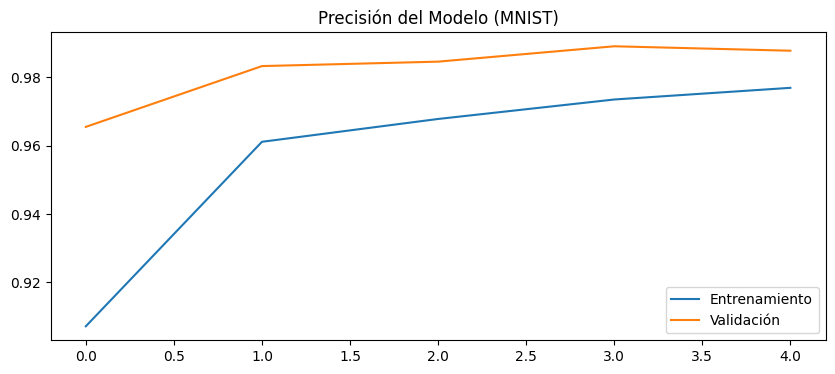

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Carga de datos (MNIST es más confiable que CIFAR-10 ante errores de servidor)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar y redimensionar para que la CNN lo acepte (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# 2. Definición del modelo robusto
model = models.Sequential([
    # Data Augmentation (image_6.png) - Ajustado para MNIST
    # No rotamos mucho porque un "6" rotado puede parecer un "9"
    layers.RandomRotation(0.05, input_shape=(28, 28, 1)),
    layers.RandomZoom(0.05),

    # Convoluciones con Strides=2 (image_3.png)
    layers.Conv2D(32, (3, 3), strides=(2, 2), activation='relu'),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), strides=(2, 2), activation='relu'),
    layers.BatchNormalization(),

    # Clasificador (image_5.png)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout al 50%
    layers.Dense(10, activation='softmax')
])

# 3. Compilación
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenamiento rápido
print("Entrenando con MNIST (Servidor de Google)...")
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    batch_size=128
)

# 5. Graficar resultados
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (MNIST)')
plt.legend()
plt.show()

**Código Integrador: Clasificación de MNIST con CNN Completa**

Iniciando entrenamiento del modelo integrador...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 64ms/step - accuracy: 0.8878 - loss: 0.3568 - val_accuracy: 0.9787 - val_loss: 0.0667
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.9561 - loss: 0.1479 - val_accuracy: 0.9826 - val_loss: 0.0527
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9665 - loss: 0.1136 - val_accuracy: 0.9840 - val_loss: 0.0521
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9701 - loss: 0.0995 - val_accuracy: 0.9857 - val_loss: 0.0426
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.9732 - loss: 0.0880 - val_accuracy: 0.9880 - val_loss: 0.0390
313/313 - 3s - 9ms/step - accuracy: 0.9880 - loss: 0.0390

Precisión final en el set de prueba: 0.9880


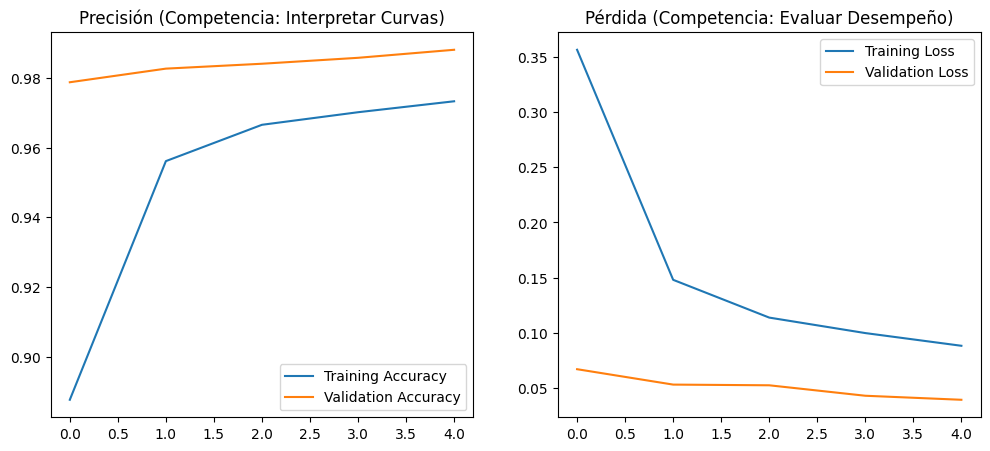

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- 1. REPRESENTACIÓN DE IMÁGENES COMO TENSORES ---
# Carga de datos MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalización a rango [0, 1] y redimensión a tensores (Batch, Altura, Anchura, Canales)
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# --- 2. CONSTRUCCIÓN DE LA ARQUITECTURA CNN COMPLETA ---
model = models.Sequential([
    # Aumento de datos (Regularización opcional para robustez)
    layers.RandomRotation(0.1, input_shape=(28, 28, 1)),
    layers.RandomZoom(0.1),

    # Capa Convolucional 1: Extracción de características (bordes)
    layers.Conv2D(32, (3, 3), activation='relu'),
    # Pooling: Reducción de dimensionalidad e invariancia espacial
    layers.MaxPooling2D((2, 2)),

    # Capa Convolucional 2: Patrones más complejos
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Aplanado para pasar a capas densas
    layers.Flatten(),

    # Capa Densa con Dropout: Regularización para evitar el sobreajuste
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Capa de Salida: Clasificación en 10 categorías (dígitos 0-9)
    layers.Dense(10, activation='softmax')
])

# --- 3. COMPILACIÓN Y ENTRENAMIENTO ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Iniciando entrenamiento del modelo integrador...")
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test), batch_size=64)

# --- 4. EVALUACIÓN DEL DESEMPEÑO DEL MODELO ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión final en el set de prueba: {test_acc:.4f}')

# --- 5. INTERPRETACIÓN DE CURVAS DE ENTRENAMIENTO ---
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Precisión (Competencia: Interpretar Curvas)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Pérdida (Competencia: Evaluar Desempeño)')
    plt.legend()
    plt.show()

plot_history(history)